# Digits parameter sweeps

Explore how `IteratedMSTEmbedding` parameters change the digits embedding. The sweep below defaults to the documented MST counts (`1, 2, 4, 8, 16, 32`), uses the same seed for each run, and reports trustworthiness alongside the plots.

The default 500 epochs and larger MST counts can take a few minutes. For a quick iteration, lower `N_EPOCHS` or shorten `VALUES`; restore 500 epochs for a final comparison.

In [6]:
from pathlib import Path
import sys

# Add the notebook helper module when running from the repository or notebooks/.
repo_root = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "notebooks" / "digits_sweep.py").is_file()),
    None,
)
if repo_root is not None:
    sys.path.insert(0, str(repo_root / "notebooks"))

from digits_sweep import load_digits_data, run_sweep

## Load and scale digits

In [7]:
X, labels = load_digits_data()
print(f"Samples: {X.shape[0]}, features: {X.shape[1]}")

Samples: 1797, features: 64


## Choose a sweep

Set `PARAMETER` to any estimator parameter, such as `"n_msts"`, `"lambda_rep"`, or `"learning_rate"`, and set `VALUES` to the candidates. `BASE_PARAMS` supplies the remaining estimator settings.

Set `N_JOBS=1` for sequential runs or `N_JOBS=2` to fit two candidates at once. Each worker builds a dense pairwise distance matrix, so keep the worker count modest for larger datasets.

In [8]:
PARAMETER = "n_msts"
VALUES = [1, 2, 4, 6, 8, 10, 16, 32, 64]

BASE_PARAMS = {
    "n_epochs": 500,
    "batch_size": 4096,
    "learning_rate": 0.05,
    "negative_ratio": 4,
    "lambda_rep": 1.0,
    "random_state": 42,
    "epsilon": 1e-4,
    "device": "auto",
}
TRUSTWORTHINESS_NEIGHBORS = 10
N_JOBS = 2

Each panel colors samples by their digit label and reports 5-fold cross-validated 5-nearest-neighbor accuracy using the 2D coordinates. Trustworthiness summarizes how well local neighborhoods in the original standardized data are preserved in 2D. Both scores are for comparison only and are not used to train the embedding. The accuracy is a transductive estimate: the embedding was fitted jointly on all unlabeled samples before the classifier folds were evaluated.

Fitting n_msts=1 ...
Fitting n_msts=2 ...


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.


Finished n_msts=1 in 0 sec
Fitting n_msts=4 ...
Finished n_msts=2 in 0 sec
Fitting n_msts=6 ...
Finished n_msts=4 in 1 sec
Fitting n_msts=8 ...
Finished n_msts=6 in 1 sec
Fitting n_msts=10 ...
Finished n_msts=8 in 2 sec
Fitting n_msts=16 ...
Finished n_msts=10 in 2 sec
Fitting n_msts=32 ...
Finished n_msts=16 in 3 sec
Fitting n_msts=64 ...
Finished n_msts=32 in 6 sec
Finished n_msts=64 in 12 sec


[Parallel(n_jobs=2)]: Done   9 out of   9 | elapsed:   18.7s finished


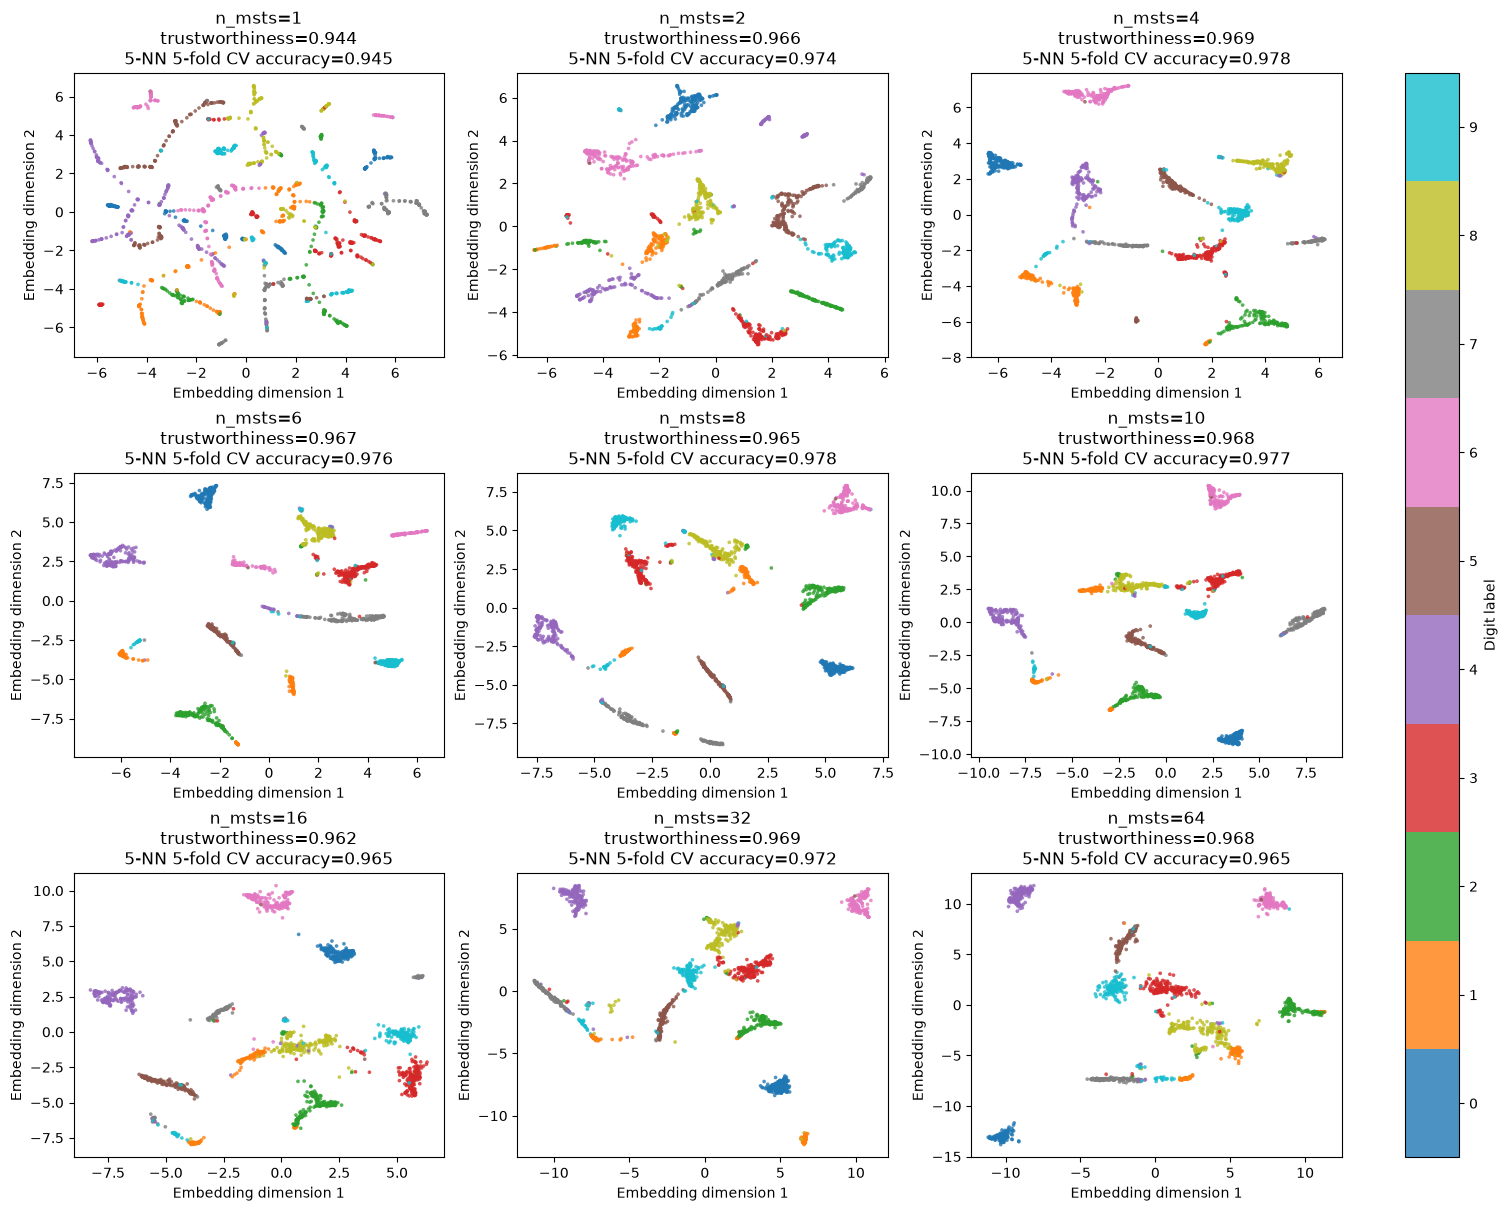

,n_msts,trustworthiness,5-NN 5-fold CV accuracy,seconds,elapsed
0,1,0.943982,0.945455,0.300612,0 sec
1,2,0.965773,0.973839,0.478729,0 sec
2,4,0.968642,0.977733,0.956454,1 sec
3,6,0.967001,0.976062,1.367797,1 sec
4,8,0.964953,0.977738,1.650833,2 sec
5,10,0.967980,0.977176,2.001559,2 sec
6,16,0.961526,0.965492,3.176822,3 sec
7,32,0.968765,0.971616,6.307599,6 sec
8,64,0.968267,0.964933,11.980225,12 sec


In [9]:
results, summary = run_sweep(
    X, labels, PARAMETER, VALUES, BASE_PARAMS,
    n_neighbors=TRUSTWORTHINESS_NEIGHBORS, n_jobs=N_JOBS,
)
summary